In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [72]:
df = sns.load_dataset("iris")
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [73]:
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.feature_selection import SelectFromModel

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline([
    ("feature_scaling", StandardScaler()),
    
])

print(pipeline)


Pipeline(steps=[('feature_scaling', StandardScaler())])


In [74]:
df = df.sample(frac = 1, random_state=42)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


In [75]:
X_train = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]][:120]
y_train = df["species"][:120]
X_test = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]][120:]
y_test = df["species"][120:]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(120, 4) (120,) (30, 4) (30,)


In [76]:
pipeline.fit(X_train)
X_train_scaled = pipeline.transform(X_train)
X_test_scaled = pipeline.transform(X_test)

In [77]:
X_train_scaled = pd.DataFrame(data = X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(data = X_test_scaled, columns = X_test.columns)

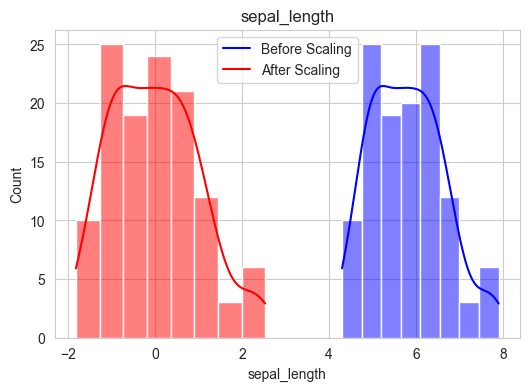

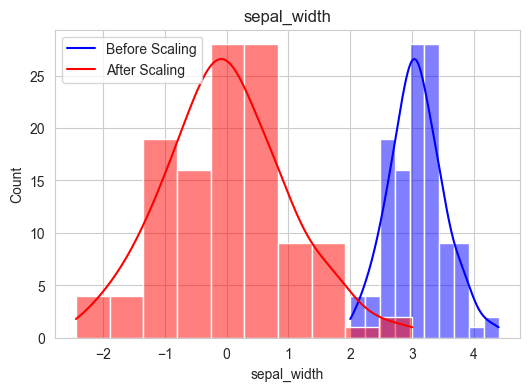

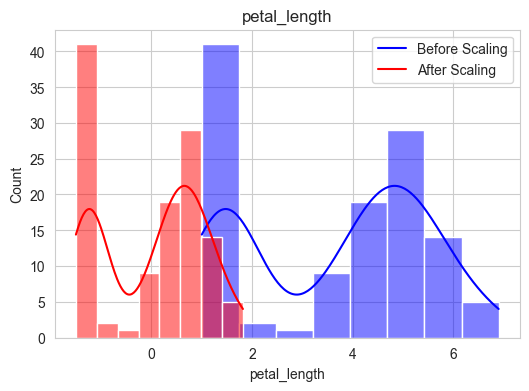

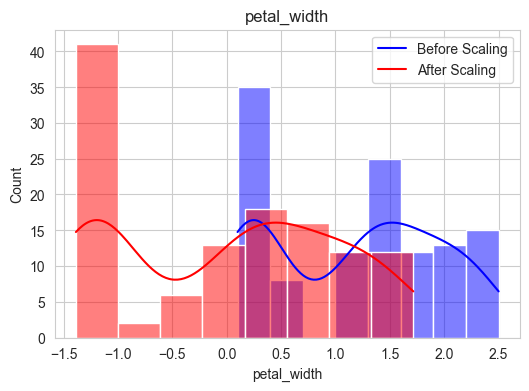

In [78]:
for col in X_train.columns:
    fig, axes = plt.subplots(figsize = (6, 4))
    
    sns.histplot(data = X_train, x = col, kde = True, color = "b", ax = axes)
    sns.histplot(data = X_train_scaled, x = col, kde= True, color = "r", ax = axes)
    axes.set_title(f"{col}")
    axes.legend(["Before Scaling", "After Scaling"])
    plt.show()
    print("\n\n")

In [79]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

X_train.head()

(120, 4) (120,) (30, 4) (30,)


,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4


In [80]:
from sklearn.feature_selection import SelectFromModel

from sklearn.tree import DecisionTreeClassifier

updated_pipeline = Pipeline([
    ("feature_scaling", StandardScaler()),
    ("feature_selection", SelectFromModel(DecisionTreeClassifier(random_state = 42))),
    ("model", DecisionTreeClassifier(random_state = 42))
])

updated_pipeline

,steps,"[('feature_scaling', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,DecisionTreeC...ndom_state=42)
,threshold,None
,prefit,False
,norm_order,1


In [81]:
updated_pipeline.fit(X_train, y_train)

,steps,"[('feature_scaling', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,DecisionTreeC...ndom_state=42)
,threshold,None
,prefit,False
,norm_order,1


In [82]:
updated_pipeline["feature_selection"]

,estimator,DecisionTreeC...ndom_state=42)
,threshold,None
,prefit,False
,norm_order,1
,max_features,None
,importance_getter,'auto'
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [84]:
updated_pipeline["feature_selection"].get_support()

array([False, False,  True,  True])